## Project Introduction

Dataset overview
> Analyzing complaint behavior and operational response patterns in the U.S. financial industry using 14M+ CFPB complaint records.

In [2]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
#Loading the dataset
df = pd.read_csv("../dataset/cfpb_cleaned_data.csv", encoding="latin1")
df.head()

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,has_narrative,has_public_response,timely_response_flag,product_category
0,2020-07-06,"credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,Other,Web,2020-07-06,Closed with explanation,YES,3730948,0,1,1,Credit
1,2019-12-26,credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,Consent not provided,Web,2019-12-26,Closed with explanation,YES,3477549,0,0,1,Credit
2,2020-05-08,"credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,Consent provided,Web,2020-05-08,Closed with explanation,YES,3642453,1,1,1,Credit
3,2024-01-05,credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report....,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,Consent provided,Web,2024-01-05,Closed with non-monetary relief,YES,8113747,1,1,1,Credit
4,2024-01-21,credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NC,Consent not provided,Web,2024-01-21,Closed with explanation,YES,8191825,0,1,1,Credit


In [4]:
df.shape

(14889543, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14889543 entries, 0 to 14889542
Data columns (total 19 columns):
 #   Column                        Dtype
---  ------                        -----
 0   date_received                 str  
 1   product                       str  
 2   sub_product                   str  
 3   issue                         str  
 4   sub_issue                     str  
 5   consumer_complaint_narrative  str  
 6   company_public_response       str  
 7   company                       str  
 8   state                         str  
 9   consumer_consent_provided     str  
 10  submitted_via                 str  
 11  date_sent_to_company          str  
 12  company_response_to_consumer  str  
 13  timely_response               str  
 14  complaint_id                  int64
 15  has_narrative                 int64
 16  has_public_response           int64
 17  timely_response_flag          int64
 18  product_category              str  
dtypes: int64(4), str(15)
memory us

In [6]:
 #Let convert the date columns to datetime format
df['date_received'] = pd.to_datetime(df['date_received'], errors='coerce')
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'], errors='coerce')

In [7]:
df.isnull().sum().sort_values(ascending=False)

consumer_complaint_narrative    11119295
company_public_response          6813136
consumer_consent_provided        2333401
company_response_to_consumer          21
sub_product                            0
date_received                          0
product                                0
issue                                  0
company                                0
state                                  0
sub_issue                              0
submitted_via                          0
date_sent_to_company                   0
timely_response                        0
complaint_id                           0
has_narrative                          0
has_public_response                    0
timely_response_flag                   0
product_category                       0
dtype: int64

In [8]:
df['company'] = df['company'].str.title()
df['company']

0              Experian Information Solutions Inc.
1                Capital One Financial Corporation
2              Experian Information Solutions Inc.
3              Experian Information Solutions Inc.
4              Experian Information Solutions Inc.
                             ...                  
14889538               Ocwen Financial Corporation
14889539                             Equifax, Inc.
14889540    Transunion Intermediate Holdings, Inc.
14889541    Transunion Intermediate Holdings, Inc.
14889542     Bank Of America, National Association
Name: company, Length: 14889543, dtype: str

### Exploratory Data Analysis

COMPLAINT SURVEY

1. What financial product generate the most complaints?

In [9]:
#financial institutions
df['product_category'].value_counts()

product_category
Credit     12388357
Debt        1086030
Loan         764201
Banking      447409
Other        203546
Name: count, dtype: int64

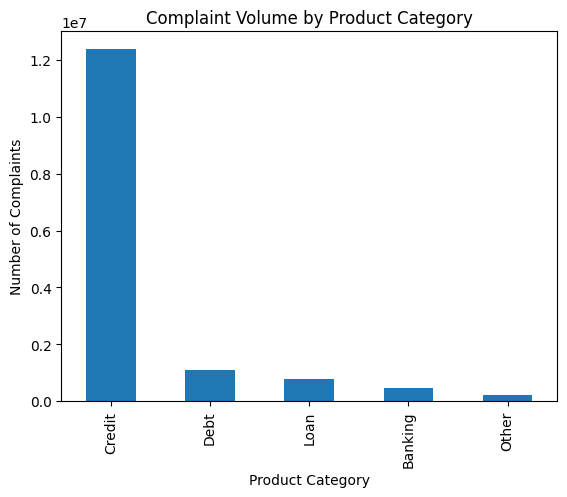

In [10]:
# Visualization 
df['product_category'].value_counts().plot(kind='bar')

plt.title("Complaint Volume by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Complaints")

plt.show()

Finding

> Credit-related products account for the overwhelming majority of complaints, with more than 12 million complaint records. Debt and loan products follow at a significantly lower volume.


Business Interpretation

> The findings suggest that credit-related financial services represent the largest source of consumer dissatisfaction within the financial sector. This may reflect widespread issues related to credit reporting accuracy, account management, and dispute resolution processes.

2. What are the most common complaint issues?

In [11]:
df['issue'].value_counts().head(10)

issue
Incorrect information on your report                                                6433582
Improper use of your report                                                         2892660
Problem with a company's investigation into an existing problem                     1778340
Problem with a credit reporting company's investigation into an existing problem     589321
Attempts to collect debt not owed                                                    428265
Written notification about debt                                                      212743
Managing an account                                                                  211089
Took or threatened to take negative or legal action                                  120599
Loan modification,collection,foreclosure                                             112296
False statements or representation                                                   110154
Name: count, dtype: int64

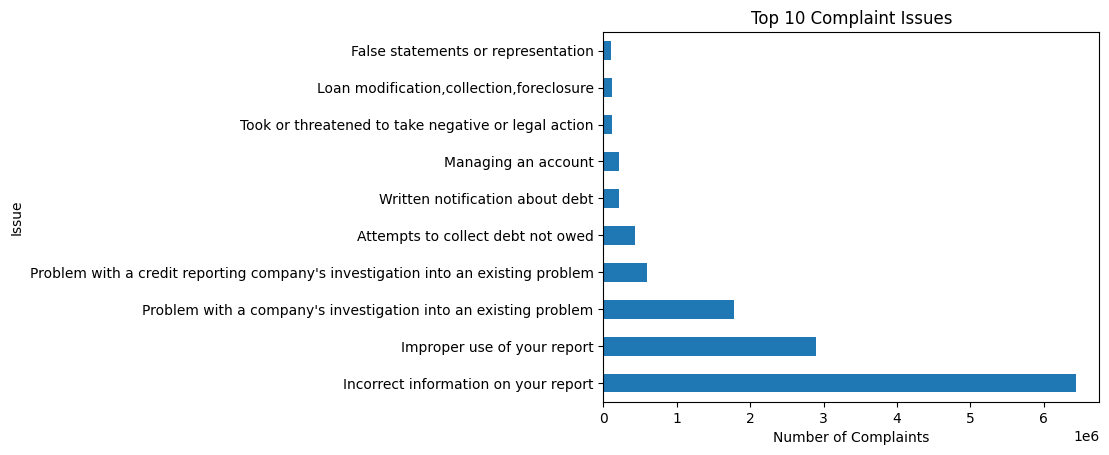

In [12]:
df['issue'].value_counts().head(10).plot(kind='barh')

plt.title("Top 10 Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")

plt.show()

Finding

> The most frequently reported issues include incorrect information on credit reports, improper use of credit reports, and problems with investigation processes.

Business Interpretation

> These findings indicate that consumer dissatisfaction is heavily concentrated around credit reporting systems and dispute investigation procedures. Persistent inaccuracies and unresolved investigations may contribute to declining consumer trust in financial reporting institutions.

3. Which companies have the most complaints?

In [13]:
df['company'].value_counts().head(10)

company
Transunion Intermediate Holdings, Inc.    3933743
Equifax, Inc.                             3908433
Experian Information Solutions Inc.       3483223
Bank Of America, National Association      177071
Wells Fargo & Company                      166343
Jpmorgan Chase & Co.                       165528
Capital One Financial Corporation          157579
Citibank, N.A.                             132208
Synchrony Financial                         77404
Block, Inc.                                 64610
Name: count, dtype: int64

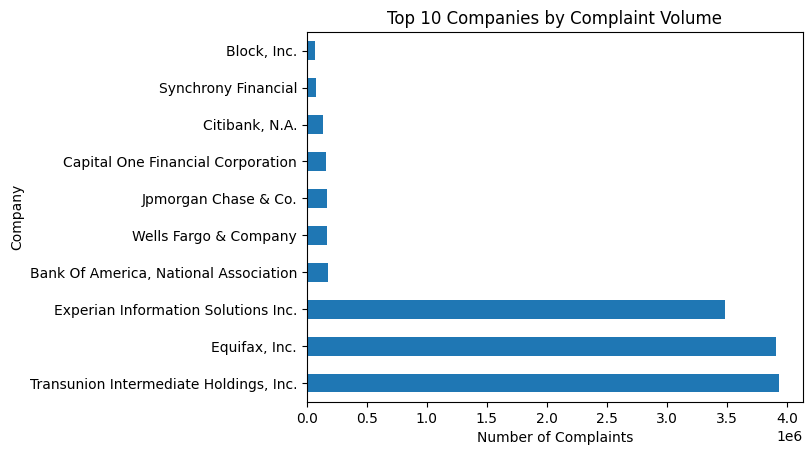

In [14]:
df['company'].value_counts().head(10).plot(kind='barh')

plt.title("Top 10 Companies by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Company")

plt.show()

Finding

> TransUnion, Equifax, and Experian account for the highest complaint volumes, significantly exceeding traditional banking institutions.

Business Interpretation

> The dominance of credit reporting agencies suggests that consumer frustration is largely driven by credit reporting practices rather than traditional banking operations. This highlights the critical role of credit bureaus in shaping customer financial experiences.

4. Do customers provide Complaint Narratives?

In [15]:
#Narrative vs no narrative
df['has_narrative'].value_counts(normalize=True)

has_narrative
0    0.746786
1    0.253214
Name: proportion, dtype: float64

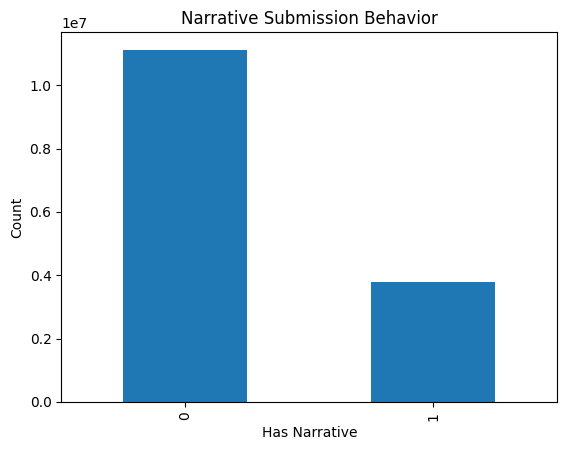

In [16]:
df['has_narrative'].value_counts().plot(kind='bar')

plt.title("Narrative Submission Behavior")
plt.xlabel("Has Narrative")
plt.ylabel("Count")

plt.show()

Finding

> Approximately 75% of complaints do not include detailed narratives, while only about 25% contain written explanations from consumers.

Business Interpretation

> The low proportion of detailed complaint narratives suggests that many consumers rely on structured complaint forms rather than extensive written explanations. However, complaints containing narratives may represent cases involving higher frustration or more complex customer experiences.

5. How Often Do Companies Respond Publicly?

In [17]:
#Public response behavior
df['has_public_response'].value_counts(normalize=True)

has_public_response
1    0.542421
0    0.457579
Name: proportion, dtype: float64

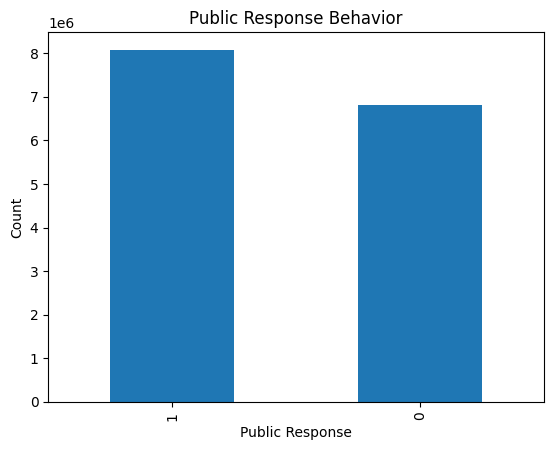

In [18]:
df['has_public_response'].value_counts().plot(kind='bar')

plt.title("Public Response Behavior")
plt.xlabel("Public Response")
plt.ylabel("Count")

plt.show()

Finding

> Slightly more than half of all complaints receive public responses from companies.

Business Interpretation

> The findings suggest that while many companies engage publicly with consumer complaints, a substantial portion of complaints still lack visible public responses. This may indicate varying transparency practices across financial institutions.

6. Which financial institution had poor response timeliness?

In [19]:
df.groupby('product_category')['timely_response_flag'].mean()

product_category
Banking    0.987204
Credit     0.998158
Debt       0.964886
Loan       0.966833
Other      0.980496
Name: timely_response_flag, dtype: float64

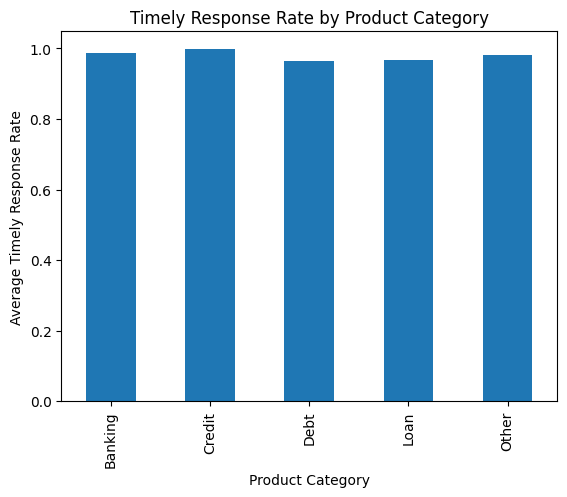

In [20]:
df.groupby('product_category')['timely_response_flag'].mean().plot(kind='bar')

plt.title("Timely Response Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Timely Response Rate")

plt.show()

Finding

> All product categories demonstrate high timely response rates, with credit-related complaints showing the strongest response performance.

Business Interpretation

> Despite extremely high complaint volumes, financial institutions maintain strong operational response timeliness. This suggests that customer dissatisfaction may stem more from response quality and issue resolution effectiveness than from response speed alone.

### Time-Based Analysis

This section explores how consumer complaint behavior changed over time across different financial product categories.

In [21]:
# Convert Date Properly
df['date_received'] = pd.to_datetime(df['date_received'], errors='coerce')
df['year'] = df['date_received'].dt.year

#### Complaint Trend Over Time

1. How has complaint volume changed over time?

In [22]:
complaints_by_year = df['year'].value_counts().sort_index()

complaints_by_year

year
2011       2536
2012      72372
2013     108213
2014     152909
2015     168274
2016     191299
2017     242756
2018     257137
2019     277249
2020     444231
2021     495956
2022     800312
2023    1292069
2024    2734287
2025    5442769
2026    2207174
Name: count, dtype: int64

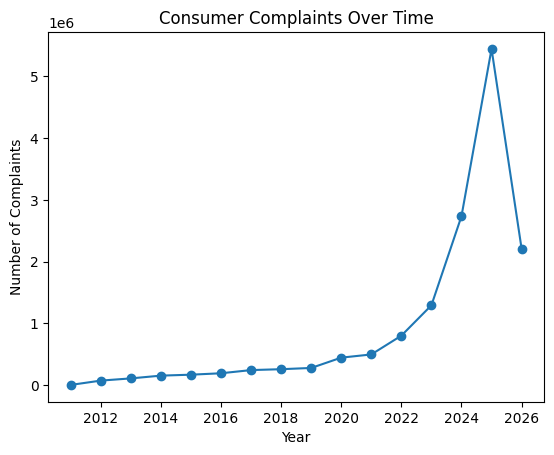

In [23]:
complaints_by_year.plot(kind='line', marker='o')

plt.title("Consumer Complaints Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")

plt.show()

Finding

> Complaint volume shows a consistent upward trend over time, with a sharp acceleration after 2020 and a peak in 2025.

2. How have complaint volumes changed across product categories over time?

In [24]:
product_trend = df.groupby(['year', 'product_category']).size().unstack()

product_trend

product_category,Banking,Credit,Debt,Loan,Other
year,,,,,
2011,NaN,1260.0,NaN,1276.0,NaN
2012,12212.0,17226.0,NaN,42934.0,NaN
2013,13388.0,27485.0,11068.0,55713.0,559.0
2014,14662.0,43212.0,39032.0,54381.0,1622.0
2015,17137.0,51567.0,39566.0,56282.0,3722.0
2016,21846.0,65144.0,40339.0,60683.0,3287.0
2017,19718.0,112488.0,47842.0,58386.0,4322.0
2018,21207.0,135839.0,51079.0,43582.0,5430.0
2019,21735.0,164384.0,46333.0,39713.0,5084.0


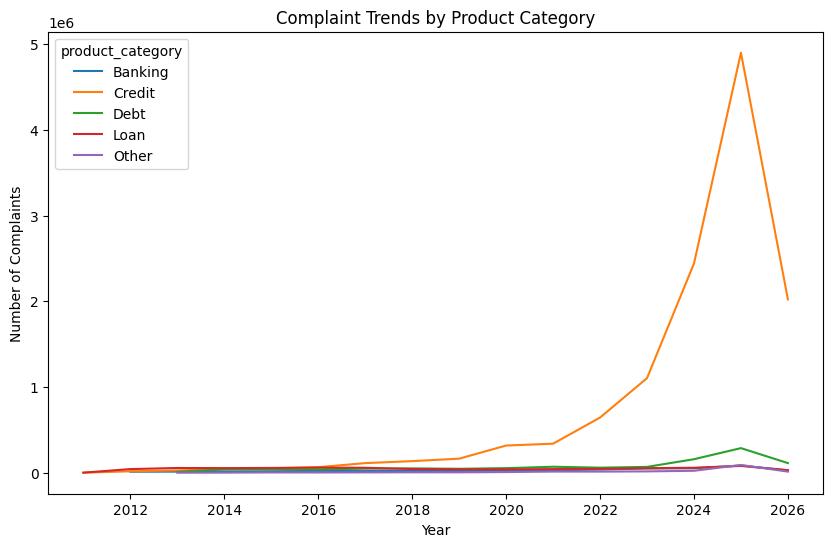

In [25]:
product_trend.plot(figsize=(10,6))

plt.title("Complaint Trends by Product Category")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")

plt.show()

Finding

> Credit-related complaints are the primary driver of overall complaint growth, especially from 2020 onward.

Business Interpretation
> The data indicates that complaint growth is not evenly distributed across financial services. Instead, it is heavily concentrated in credit-related products, suggesting that issues within credit reporting systems are the dominant contributor to rising complaint volumes.

3. Has response timeliness improved or declined over time?

In [26]:
timely_trend = df.groupby('year')['timely_response_flag'].mean()
timely_trend

year
2011    0.901025
2012    0.965360
2013    0.988310
2014    0.977117
2015    0.972527
2016    0.966001
2017    0.971959
2018    0.982850
2019    0.984999
2020    0.989704
2021    0.987543
2022    0.993525
2023    0.995712
2024    0.997160
2025    0.995476
2026    0.996325
Name: timely_response_flag, dtype: float64

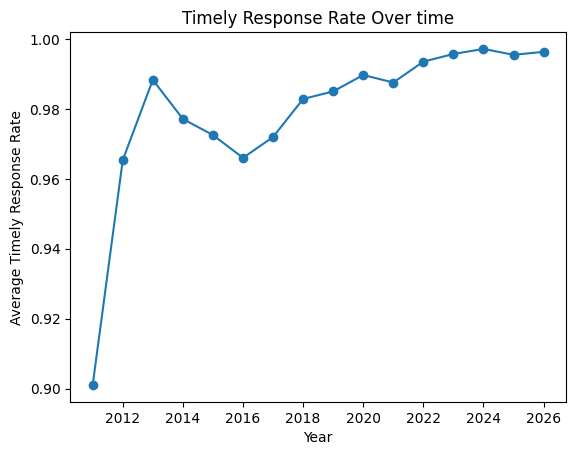

In [27]:
timely_trend.plot(kind='line', marker='o')
plt.title("Timely Response Rate Over time")
plt.xlabel("Year")
plt.ylabel("Average Timely Response Rate")
plt.show()

Finding 
> Timely response rates have consistently improved over time, stabilizing above 99% in recent years.

Business Interpretation

> Operational response efficiency has improved significantly across the financial sector, indicating stronger internal complaint-handling systems over time.

4. Are consumers providing more detailed complaint narratives over time?

In [28]:
narrative_trend = df.groupby('year')['has_narrative'].mean()
narrative_trend

year
2011    0.000000
2012    0.000000
2013    0.000000
2014    0.000000
2015    0.325202
2016    0.406542
2017    0.474056
2018    0.460428
2019    0.450267
2020    0.392377
2021    0.410448
2022    0.421292
2023    0.377238
2024    0.297844
2025    0.224478
2026    0.018494
Name: has_narrative, dtype: float64

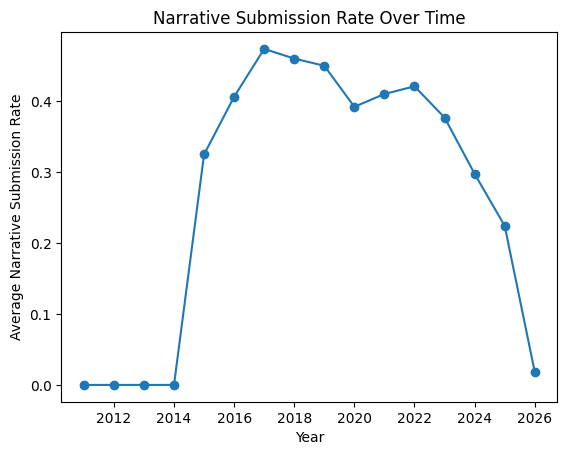

In [29]:
narrative_trend.plot(kind='line', marker='o')
plt.title("Narrative Submission Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Narrative Submission Rate")
plt.show()

Finding

> Consumer narrative submissions increased initially around 2016–2018 as its peaks year and has shown steady declined in recent years.

Business Interpretation

> This trend suggests a shift in how consumers engage with complaint systems, moving from detailed explanations toward more structured or simplified complaint submissions.

### Root Cause Analysis

1. What are the most common issues within Credit complaints?

In [ ]:
credit_df = df[df['product_category'] == 'Credit']

credit_df['issue'].value_counts().head(10)

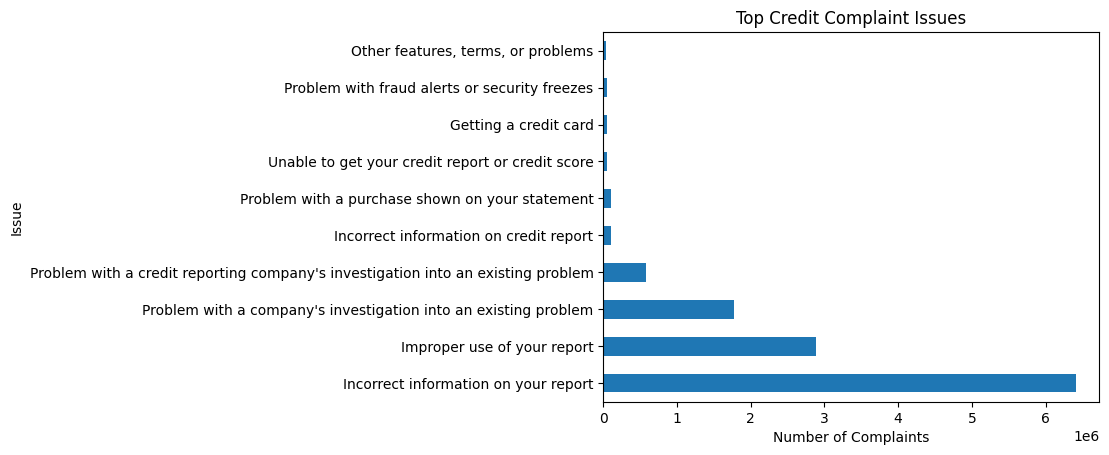

In [ ]:
credit_df['issue'].value_counts().head(10).plot(kind='barh')
plt.title("Top Credit Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.show()

Finding
> Most credit complaints are not about products failing, they are about wrong or inaccurate information being shown on credit reports.

2. How do complaint patterns differ between Credit and Debt?

In [ ]:
df.groupby(['product_category', 'issue']).size().unstack().fillna(0)

issue,APR or interest rate,"Account opening, closing, or management",Account terms and changes,Adding money,Advertising,Advertising and marketing,"Advertising and marketing, including promotional offers","Advertising, marketing or disclosures",Application processing delay,"Application, originator, mortgage broker",...,Unexpected or other fees,Unexpected/Other fees,Unsolicited issuance of credit card,Using a debit or ATM card,Vehicle was damaged or destroyed the vehicle,Vehicle was repossessed or sold the vehicle,"Was approved for a loan, but didn't receive money","Was approved for a loan, but didn't receive the money",Written notification about debt,Wrong amount charged or received
product_category,,,,,,,,,,,,,,,,,,,,,
Banking,0.0,37959.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6144.0,0.0,0.0,0.0,0.0,0.0,0.0
Credit,5506.0,0.0,0.0,0.0,352.0,2926.0,17589.0,0.0,540.0,0.0,...,3367.0,0.0,1853.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Debt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,212743.0,0.0
Loan,0.0,0.0,484.0,0.0,0.0,0.0,0.0,0.0,0.0,17216.0,...,0.0,0.0,0.0,0.0,182.0,665.0,109.0,500.0,0.0,0.0
Other,0.0,0.0,0.0,202.0,214.0,33.0,0.0,77.0,0.0,0.0,...,4389.0,103.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1977.0


Finding
> Credit complaints are heavily centered around information accuracy and dispute investigations, while debt complaints are more about how debts are communicated and enforced.

3. Which product category has the most investigation failures

In [ ]:
df[df['issue'].str.contains('investigation', case=False, na=False)]['product_category'].value_counts()

product_category
Credit     2383682
Loan          8654
Banking        495
Name: count, dtype: int64

Finding 
> Almost all investigation-related complaints are concentrated in credit products.

4. Do certain issues get more detailed complaints?

In [ ]:
df.groupby('has_narrative')['issue'].value_counts().head(10)

has_narrative  issue                                                                           
0              Incorrect information on your report                                                5231109
               Improper use of your report                                                         2229599
               Problem with a company's investigation into an existing problem                     1430114
               Problem with a credit reporting company's investigation into an existing problem     338935
               Attempts to collect debt not owed                                                    250238
               Written notification about debt                                                      127935
               Managing an account                                                                  115873
               Loan modification,collection,foreclosure                                             101508
               Took or threatened to take negati

5. What issues dominate for top companies?

In [ ]:
top_companies = df['company'].value_counts().head(5).index

df[df['company'].isin(top_companies)]['issue'].value_counts().head(10)

issue
Incorrect information on your report                                                6027896
Improper use of your report                                                         2686186
Problem with a company's investigation into an existing problem                     1696807
Problem with a credit reporting company's investigation into an existing problem     527220
Incorrect information on credit report                                                97519
Attempts to collect debt not owed                                                     86384
Written notification about debt                                                       67201
Managing an account                                                                   51858
Unable to get your credit report or credit score                                      51352
Loan modification,collection,foreclosure                                              42447
Name: count, dtype: int64

### SEGMENTATION 

We are trying to answer:

> Are there different types of complainants, and how do they behave differently?

In [ ]:
# Build Behavior Features
df['has_narrative'] = df['consumer_complaint_narrative'].notna().astype(int)
df['has_public_response'] = df['company_public_response'].notna().astype(int)
df['is_credit'] = (df['product_category'] == 'Credit').astype(int)
df['is_debt'] = (df['product_category'] == 'Debt').astype(int)
df['is_banking'] = (df['product_category'] == 'Banking').astype(int)

Behavioral Segments

In [ ]:
conditions = [
    (df['has_narrative'] == 1) & (df['has_public_response'] == 1),
    (df['has_narrative'] == 0) & (df['has_public_response'] == 0),
    (df['is_credit'] == 1) & (df['has_narrative'] == 0)
]

choices = [
    'High Engagement',
    'Low Engagement',
    'System-Driven Credit Complaint'
]

df['segment'] = np.select(conditions, choices, default='Other')

Segment Distribution

In [ ]:
df['segment'].value_counts()

segment
System-Driven Credit Complaint    5603952
Low Engagement                    5063330
Other                             2201819
High Engagement                   2020442
Name: count, dtype: int64

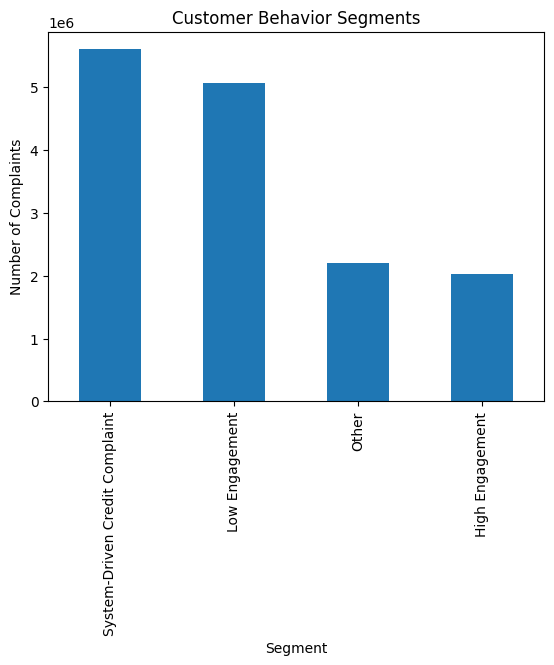

In [ ]:
df['segment'].value_counts().plot(kind='bar')
plt.title("Customer Behavior Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Complaints")
plt.show()

Finding

> The largest segment in the dataset is the System-Driven Credit Complaint group, followed closely by the Low Engagement segment. Together, these two groups account for most complaints in the dataset.

Business Interpretation

> What stands out here is that the complaint system is dominated by repetitive credit-related issues and low-interaction complaints. Most consumers are not submitting long explanations or deeply engaging with the process. Instead, they appear to be reporting recurring issues in a fast and structured way.

### Behavioral Segmentation 
> Now we compare how each segment behaves.

1. Timeliness per segment

In [ ]:
df.groupby('segment')['timely_response_flag'].mean()

segment
High Engagement                   0.994610
Low Engagement                    0.991560
Other                             0.982286
System-Driven Credit Complaint    0.999398
Name: timely_response_flag, dtype: float64

Finding

> All complaint segments received very high timely response rates, especially the System-Driven Credit Complaint segment, which had the highest response consistency.

Business Interpretation

> This suggests that companies have become highly efficient at processing complaints operationally, even when complaint volumes are extremely large. What is interesting, though, is that fast responses continue to exist alongside repeated complaint patterns, especially in credit reporting categories.

2. Product distribution per segment

In [ ]:
df.groupby('segment')['product_category'].value_counts()

segment                         product_category
High Engagement                 Credit              1632618
                                Debt                 159090
                                Loan                 114828
                                Banking               96789
                                Other                 17117
Low Engagement                  Credit              4051946
                                Debt                 455951
                                Loan                 346698
                                Banking              146363
                                Other                 62372
Other                           Credit              1099841
                                Debt                 470989
                                Loan                 302675
                                Banking              204257
                                Other                124057
System-Driven Credit Complaint  Credit             

Finding

> Credit-related products dominate every major complaint segment, especially the System-Driven and High Engagement groups. Debt and Loan complaints appear far less frequently in comparison.

Business Interpretation

When looking across segments, one pattern becomes very clear:

> the financial complaint ecosystem is heavily centered around credit reporting activity.

Whether consumers are highly engaged or minimally engaged, most complaints still trace back to credit-related problems.

3. Issue patterns per segment

In [ ]:
df.groupby('segment')['issue'].value_counts()

segment                         issue                                                                           
High Engagement                 Incorrect information on your report                                                732064
                                Improper use of your report                                                         400796
                                Problem with a company's investigation into an existing problem                     218193
                                Problem with a credit reporting company's investigation into an existing problem    148451
                                Attempts to collect debt not owed                                                    67929
                                                                                                                     ...  
System-Driven Credit Complaint  Problems at the end of the loan or lease                                                 3
                          

Finding

> Across both the High Engagement and System-Driven segments, the same issues repeatedly appear:

    - incorrect information on reports
    - improper use of reports
    - investigation-related problems

### TEXT ANALYSIS

Create a Text Dataset
> We only want complaints that actually contain narratives.

In [ ]:
text_df = df[df['consumer_complaint_narrative'].notna()].copy()

In [ ]:
# Text cleaning 
import re

text_df['clean_text'] = text_df['consumer_complaint_narrative'].str.lower()

text_df['clean_text'] = text_df['clean_text'].apply(
    lambda x: re.sub(r'[^a-z\s]', '', x)
)

In [ ]:
#Remove stop words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

#Adding Stopwords
custom_stopwords = {
    'xxxx',
    'xxxxxxxx',
    'xx',
    'usc',
    'section',
    'act',
    'fcra'
}

stop_words = set(ENGLISH_STOP_WORDS).union(custom_stopwords)

text_df['clean_text'] = text_df['clean_text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

Let discover what customers talk about most.

In [ ]:
from collections import Counter

word_counts = Counter()

for text in text_df['clean_text'].dropna():
    words = text.split()
    word_counts.update(words)

word_counts.most_common(20)

[('credit', 7685952),
 ('account', 5374682),
 ('report', 4591612),
 ('information', 4485912),
 ('reporting', 3692996),
 ('consumer', 3527496),
 ('accounts', 2368398),
 ('payment', 1752737),
 ('debt', 1633404),
 ('inaccurate', 1392414),
 ('date', 1203254),
 ('late', 1175476),
 ('agency', 1171337),
 ('balance', 1160375),
 ('did', 1151758),
 ('fair', 1140784),
 ('dispute', 1136211),
 ('identity', 1121339),
 ('number', 1114893),
 ('b', 1107516)]

In [ ]:
# Convert to DataFrame
common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=['word', 'count']
)

common_words

,word,count
0,credit,7685952
1,account,5374682
2,report,4591612
3,information,4485912
4,reporting,3692996
5,consumer,3527496
6,accounts,2368398
7,payment,1752737
8,debt,1633404
9,inaccurate,1392414


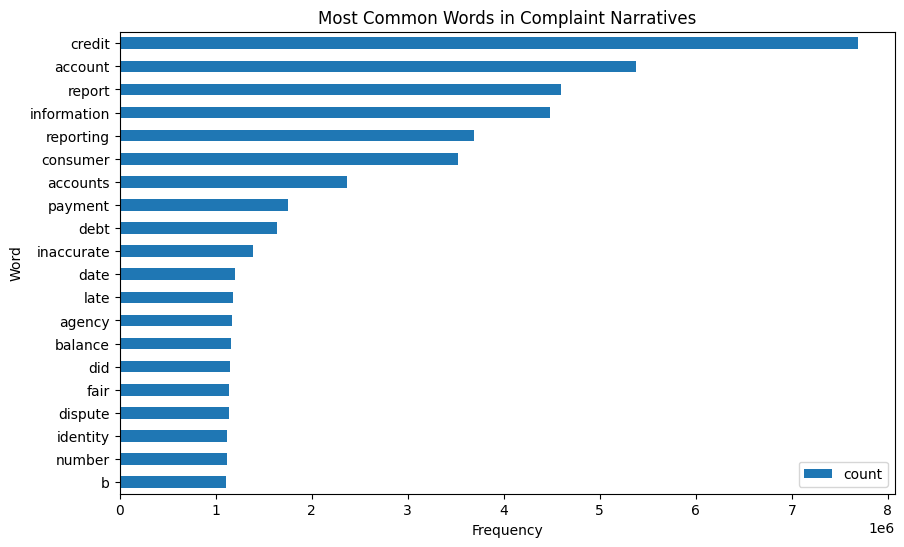

In [ ]:
# Visualize common words
common_words.sort_values(by='count').plot(
    kind='barh',
    x='word',
    y='count',
    figsize=(10,6)
)

plt.title("Most Common Words in Complaint Narratives")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### Sentiment Analysis

In [ ]:
from textblob import TextBlob

sample_df = text_df.sample(50000, random_state=42)
sample_df['sentiment_score'] = sample_df['clean_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [ ]:
#Convert Score to Labels
def get_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

sample_df['sentiment'] = sample_df['sentiment_score'].apply(get_sentiment)

In [ ]:
#check distribution
sample_df['sentiment'].value_counts(normalize=True)

sentiment
Positive    0.48630
Negative    0.38552
Neutral     0.12818
Name: proportion, dtype: float64

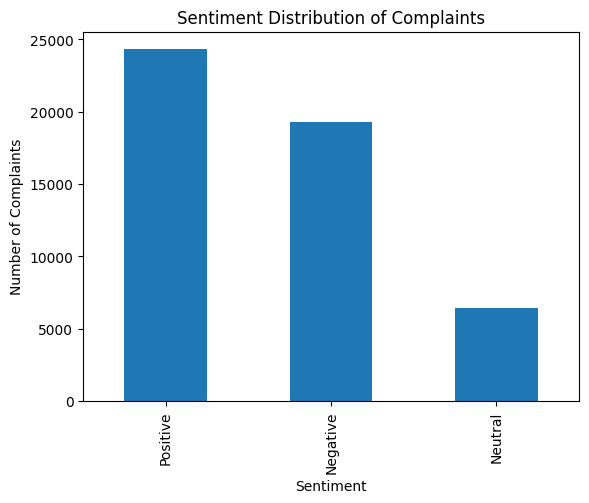

In [ ]:
#Visualization
sample_df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution of Complaints")
plt.xlabel("Sentiment")
plt.ylabel("Number of Complaints")

plt.show()

In [ ]:
from wordcloud import WordCloud

In [ ]:
# Generate Text
text = ' '.join(sample_df['clean_text'].dropna())

# Create a word count
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

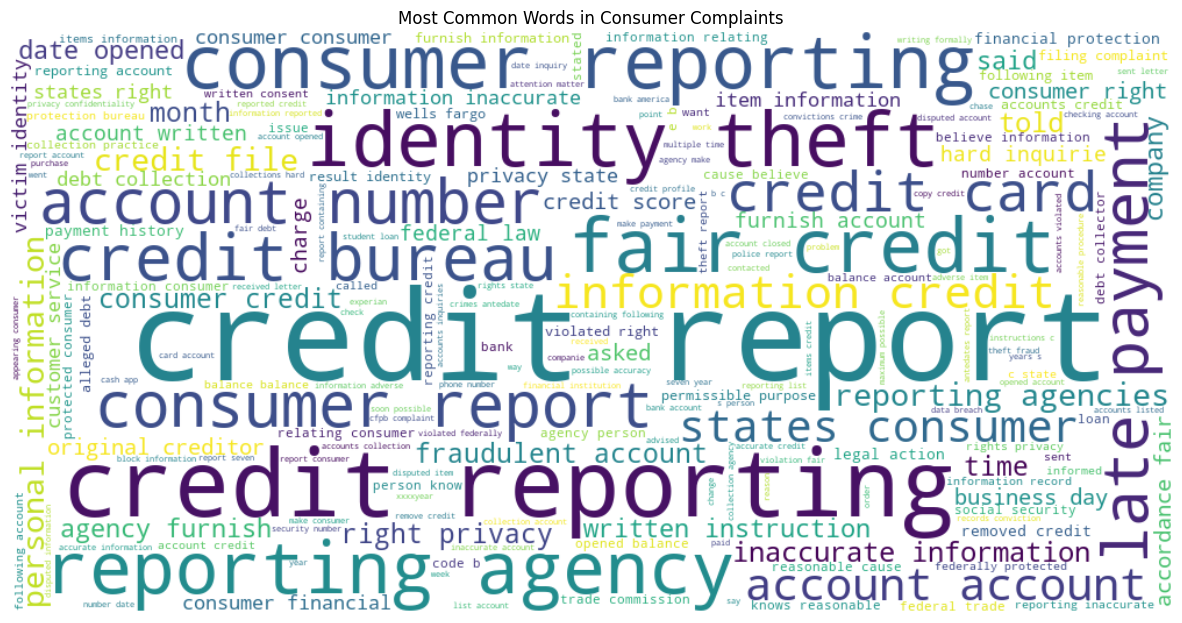

In [ ]:
# Visualize 
plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Most Common Words in Consumer Complaints")

plt.show()